# 🧠 Prédiction de la Maladie d'Alzheimer
## Pipeline Machine Learning complet — Dataset ADNI

**Objectif** : Prédire le diagnostic d'un patient parmi 3 classes :
- **CN** (Cognitively Normal)— Cognitivement Normal (pas de maladie)
- **LMCI** (Late Mild Cognitive Impairment)— Légère déficience cognitive (stade intermédiaire)
- **AD** (Alzheimer’s Disease)— Alzheimer diagnostiqué

**Modèles utilisés** : Régression Logistique · Arbre de Décision · Random Forest · XGBoost

---

## 1. Importation des Libraries

In [5]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Modèles Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métriques d'évaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Affichage propre
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("Toutes les libraries sont importées avec succès !")

Toutes les libraries sont importées avec succès !


## 2. Chargement du Fichier Nettoyé

> Ce fichier `alzheimer_clean.csv` est produit par le script R de nettoyage.  
> Dans la nouvelle version, le dataset nettoyé contient **plus de variables** que l’ancienne version :
> `AGE`, `PTGENDER`, `PTEDUCAT`, `PTETHCAT`, `PTRACCAT`, `APOE4`, `MMSE`, `imputed_genotype`, `APOE Genotype`, et la target `DX.bl`.
>
> L’objectif est maintenant de garder ces variables, puis de laisser Python encoder automatiquement les variables catégorielles pour le Machine Learning.


In [7]:
# Charger le fichier CSV nettoyé (produit par le script R)
df = pd.read_csv("alzheimer_clean.csv")

print("Dimensions :", df.shape)
print("\nColonnes :", df.columns.tolist())
print("\nPremières lignes :")
display(df.head())

# Vérification importante : la target doit exister
if 'DX.bl' not in df.columns:
    print("⚠️ Attention : la colonne target 'DX.bl' n'existe pas dans ce fichier.")
    print("Ajoute DX.bl dans le fichier nettoyé, sinon le modèle ne peut pas apprendre le diagnostic.")
else:
    print("\n✅ Target trouvée : DX.bl")


Dimensions : (627, 10)

Colonnes : ['DX.bl', 'AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT', 'APOE4', 'MMSE', 'imputed_genotype', 'APOE Genotype']

Premières lignes :


,DX.bl,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,APOE4,MMSE,imputed_genotype,APOE Genotype
0,AD,81.3,1,18,Not Hisp/Latino,White,1,20,True,34
1,LMCI,67.5,1,10,Hisp/Latino,White,0,27,False,33
2,CN,73.7,1,16,Not Hisp/Latino,White,0,29,True,33
3,LMCI,80.4,0,13,Not Hisp/Latino,White,0,25,True,33
4,AD,73.9,0,12,Not Hisp/Latino,White,1,24,True,34



✅ Target trouvée : DX.bl


In [8]:
# Statistiques descriptives
print("=== STATISTIQUES DESCRIPTIVES ===")
print(df.describe())
print("\n=== TYPES DES COLONNES ===")
print(df.dtypes)
print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

=== STATISTIQUES DESCRIPTIVES ===
              AGE    PTGENDER    PTEDUCAT       APOE4        MMSE  \
count  627.000000  627.000000  627.000000  627.000000  627.000000   
mean    75.161882    0.578947   15.612440    0.599681   26.921850   
std      6.689979    0.494122    2.978845    0.683582    2.563934   
min     55.100000    0.000000    6.000000    0.000000   20.000000   
25%     71.200000    0.000000   13.000000    0.000000   25.000000   
50%     75.400000    1.000000   16.000000    0.000000   27.000000   
75%     80.000000    1.000000   18.000000    1.000000   29.000000   
max     89.600000    1.000000   20.000000    2.000000   30.000000   

       APOE Genotype  
count     627.000000  
mean       33.658692  
std         4.785321  
min        22.000000  
25%        33.000000  
50%        33.000000  
75%        34.000000  
max        44.000000  

=== TYPES DES COLONNES ===
DX.bl                object
AGE                 float64
PTGENDER              int64
PTEDUCAT              int

## 3. Analyse Exploratoire (EDA)

Avant de modéliser, on visualise les données pour mieux comprendre les patterns.

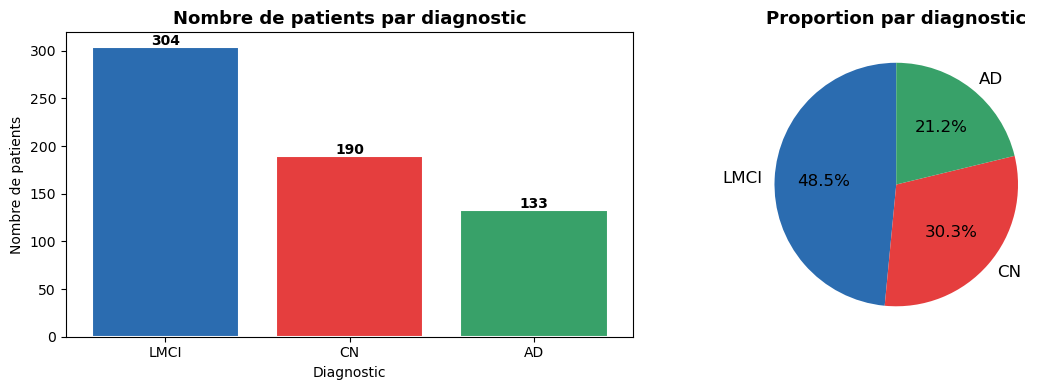

Répartition :
DX.bl
LMCI    304
CN      190
AD      133
Name: count, dtype: int64


In [10]:
# Graphique 1 : Distribution de la TARGET
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['DX.bl'].value_counts()
colors_bar = ['#2b6cb0', '#e53e3e', '#38a169']

axes[0].bar(counts.index, counts.values, color=colors_bar, edgecolor='white', linewidth=1.5)
axes[0].set_title('Nombre de patients par diagnostic', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diagnostic')
axes[0].set_ylabel('Nombre de patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors_bar, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proportion par diagnostic', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print("Répartition :")
print(df['DX.bl'].value_counts())

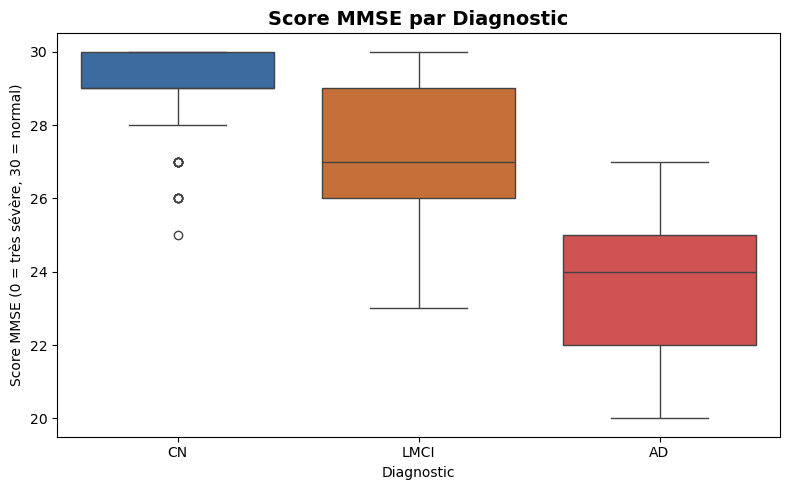

Moyenne MMSE par groupe :
DX.bl
AD      23.52
CN      29.12
LMCI    27.04
Name: MMSE, dtype: float64


In [11]:
# Graphique 2 : MMSE par diagnostic
# Le score MMSE diminue avec la sévérité de la maladie
plt.figure(figsize=(8, 5))
order = ['CN', 'LMCI', 'AD']
palette = {'CN': '#2b6cb0', 'LMCI': '#dd6b20', 'AD': '#e53e3e'}

sns.boxplot(data=df, x='DX.bl', y='MMSE', order=order, palette=palette)
plt.title('Score MMSE par Diagnostic', fontsize=14, fontweight='bold')
plt.xlabel('Diagnostic')
plt.ylabel('Score MMSE (0 = très sévère, 30 = normal)')
plt.tight_layout()
plt.show()

print("Moyenne MMSE par groupe :")
print(df.groupby('DX.bl')['MMSE'].mean().round(2))

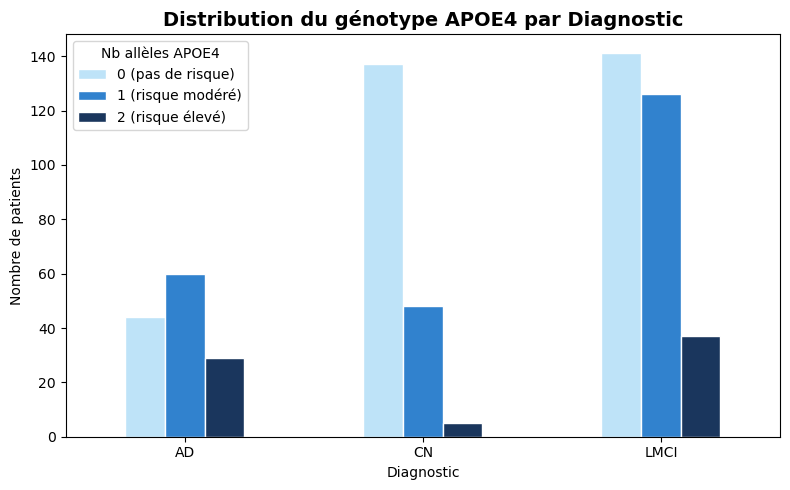

In [12]:
# Graphique 3 : Distribution APOE4 par diagnostic
apoe_cross = pd.crosstab(df['DX.bl'], df['APOE4'])
apoe_cross.plot(kind='bar', stacked=False, figsize=(8, 5),
                color=['#bee3f8', '#3182ce', '#1a365d'], edgecolor='white')
plt.title('Distribution du génotype APOE4 par Diagnostic', fontsize=14, fontweight='bold')
plt.xlabel('Diagnostic')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=0)
plt.legend(title='Nb allèles APOE4', labels=['0 (pas de risque)', '1 (risque modéré)', '2 (risque élevé)'])
plt.tight_layout()
plt.show()

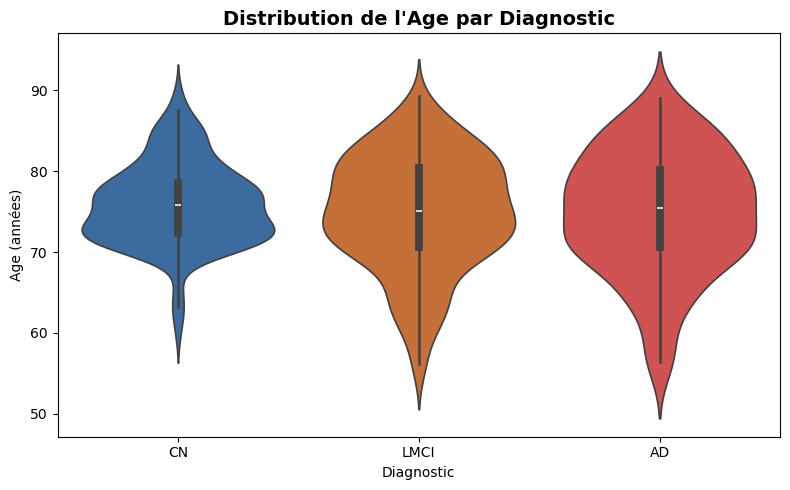

Age moyen par groupe :
DX.bl
AD      74.8
CN      75.9
LMCI    74.9
Name: AGE, dtype: float64


In [13]:
# Graphique 4 : Age par diagnostic
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='DX.bl', y='AGE', order=['CN', 'LMCI', 'AD'],
               palette={'CN': '#2b6cb0', 'LMCI': '#dd6b20', 'AD': '#e53e3e'})
plt.title("Distribution de l'Age par Diagnostic", fontsize=14, fontweight='bold')
plt.xlabel('Diagnostic')
plt.ylabel('Age (années)')
plt.tight_layout()
plt.show()

print("Age moyen par groupe :")
print(df.groupby('DX.bl')['AGE'].mean().round(1))

### Graphiques supplémentaires pour les nouvelles variables

Comme le dataset nettoyé contient maintenant plus de variables, on ajoute des schémas pour les variables catégorielles : origine ethnique, race, génotype APOE et imputation du génotype.


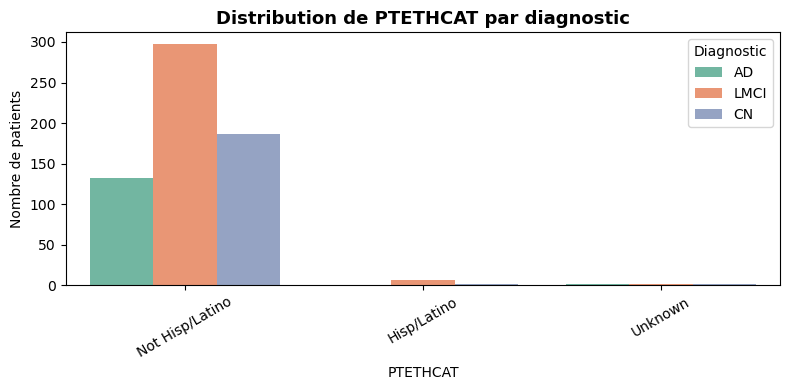

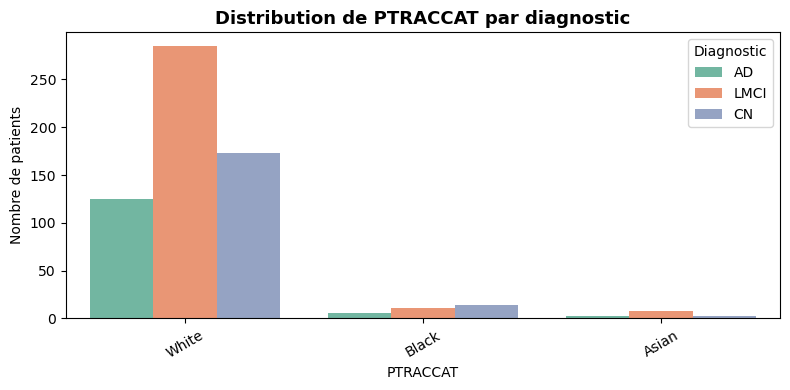

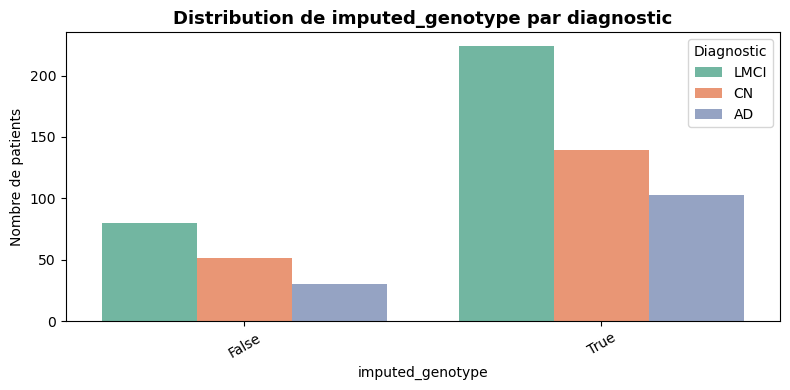

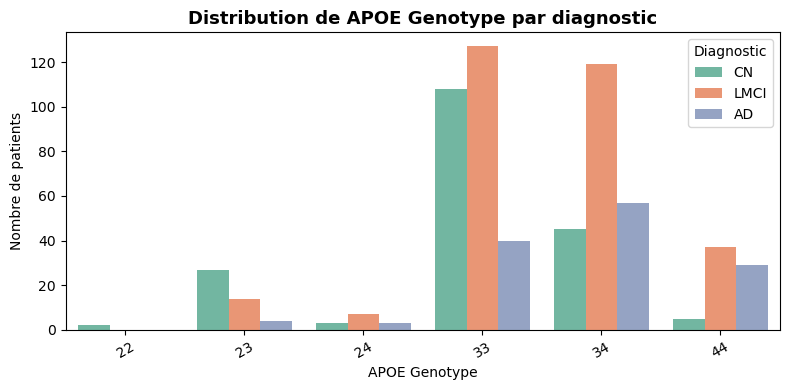

In [15]:
# Graphiques supplémentaires : variables catégorielles selon le diagnostic
cat_columns_to_plot = ['PTETHCAT', 'PTRACCAT', 'imputed_genotype', 'APOE Genotype']

for col in cat_columns_to_plot:
    if col in df.columns and 'DX.bl' in df.columns:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=col, hue='DX.bl', palette='Set2')
        plt.title(f"Distribution de {col} par diagnostic", fontsize=13, fontweight='bold')
        plt.xlabel(col)
        plt.ylabel("Nombre de patients")
        plt.xticks(rotation=30)
        plt.legend(title="Diagnostic")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Colonne non trouvée ou target manquante : {col}")


## Préparation des donnée

In [17]:
# Préparation pour corrélation

df_corr = df.copy()

# Encoder la target
mapping_target = {'CN': 0, 'LMCI': 1, 'AD': 2}
df_corr['DX_num'] = df_corr['DX.bl'].map(mapping_target)

# Supprimer la target texte
features_for_corr = df_corr.drop(columns=['DX.bl'])

# Encoder variables catégorielles
features_encoded_corr = pd.get_dummies(features_for_corr, drop_first=False)

# Convertir en numérique
features_encoded_corr = features_encoded_corr.astype(float)

print("Données prêtes pour corrélation")
features_encoded_corr.head()

Données prêtes pour corrélation


,AGE,PTGENDER,PTEDUCAT,APOE4,MMSE,imputed_genotype,APOE Genotype,DX_num,PTETHCAT_Hisp/Latino,PTETHCAT_Not Hisp/Latino,PTETHCAT_Unknown,PTRACCAT_Asian,PTRACCAT_Black,PTRACCAT_White
0,81.3,1.0,18.0,1.0,20.0,1.0,34.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0
1,67.5,1.0,10.0,0.0,27.0,0.0,33.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,73.7,1.0,16.0,0.0,29.0,1.0,33.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,80.4,0.0,13.0,0.0,25.0,1.0,33.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,73.9,0.0,12.0,1.0,24.0,1.0,34.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0


### Analyse de corrélation
Nous analysons les relations entre les variables et leur influence sur la cible.

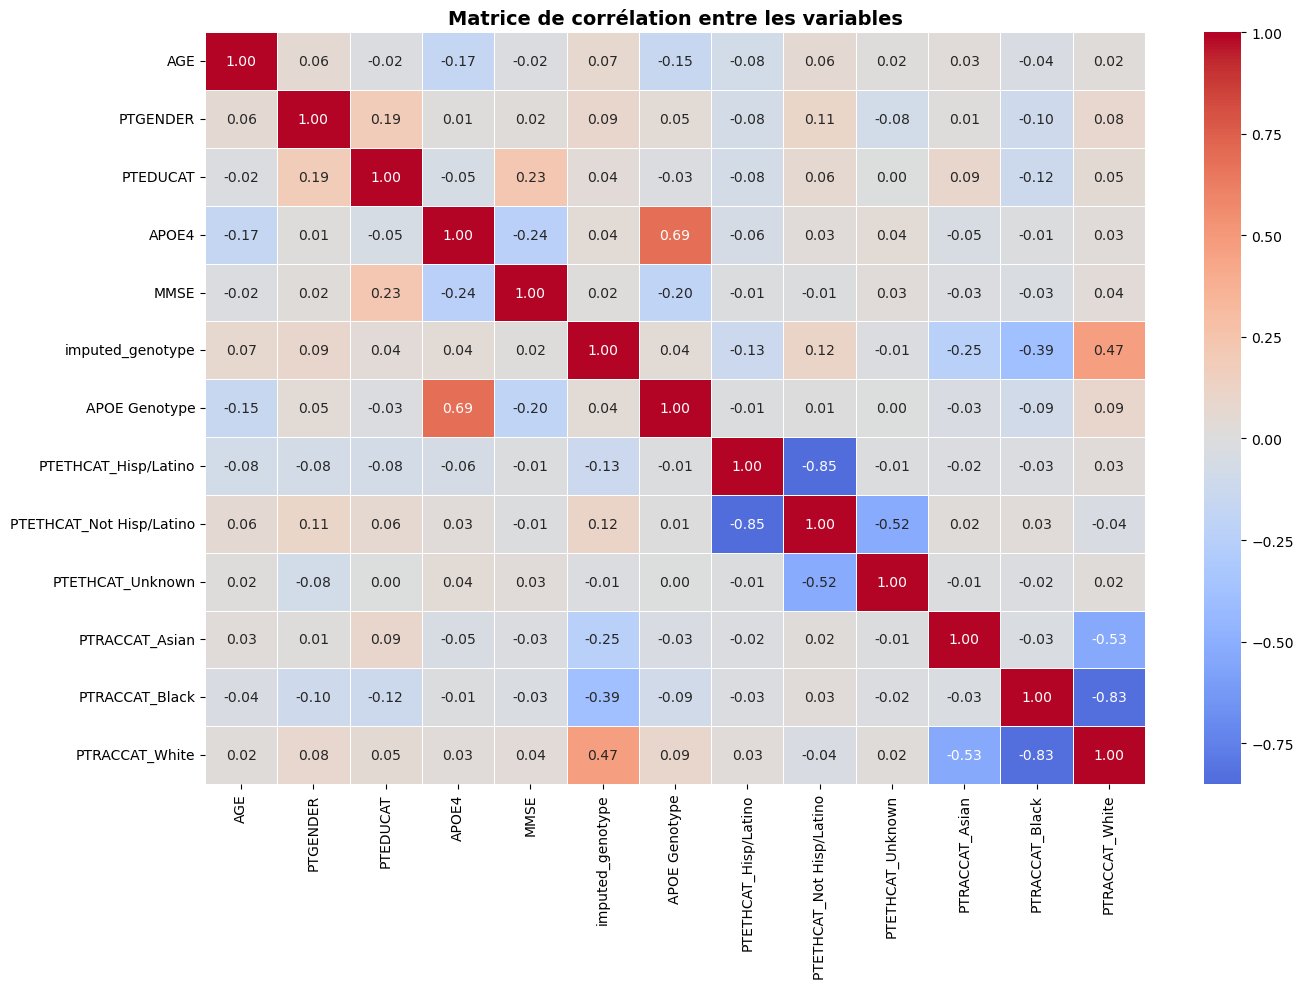

In [19]:
# Corrélation entre variables

corr_features = features_encoded_corr.drop(columns=['DX_num']).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_features,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matrice de corrélation entre les variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

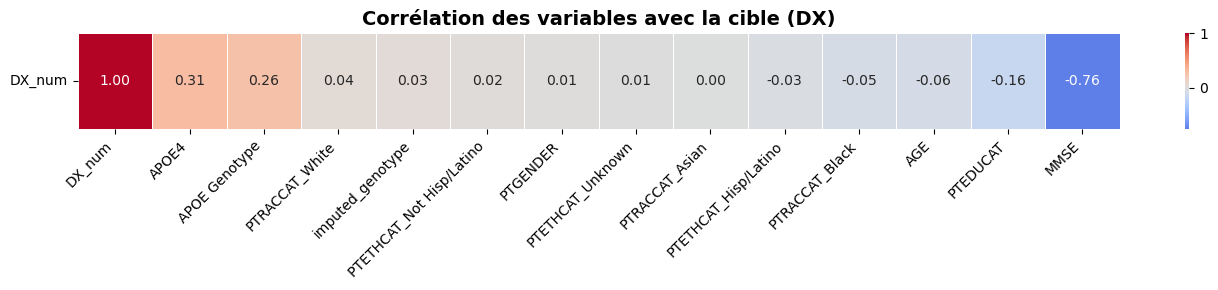

In [20]:
# Corrélation avec la cible (horizontal)

corr_with_target = (
    features_encoded_corr
    .corr()[['DX_num']]
    .sort_values(by='DX_num', ascending=False)
)

# TRANSPOSE → horizontal
corr_with_target_T = corr_with_target.T

plt.figure(figsize=(14, 3))
sns.heatmap(
    corr_with_target_T,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Corrélation des variables avec la cible (DX)", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
print("Variables les plus corrélées avec la cible :")
display(corr_with_target)

Variables les plus corrélées avec la cible :


,DX_num
DX_num,1.000000
APOE4,0.308887
APOE Genotype,0.264960
PTRACCAT_White,0.043848
imputed_genotype,0.032632
PTETHCAT_Not Hisp/Latino,0.017063
PTGENDER,0.013612
PTETHCAT_Unknown,0.008854
PTRACCAT_Asian,0.002858
PTETHCAT_Hisp/Latino,-0.025403


### Amélioration de la sélection des variables

Après analyse de la matrice de corrélation, nous avons observé une forte corrélation entre **APOE Genotype** et **APOE4**.

Cela indique que ces deux variables contiennent des informations génétiques similaires, ce qui peut introduire de la redondance et de la multicolinéarité dans le modèle.

Afin de simplifier le modèle et d’éviter cette duplication, nous avons décidé de :

- **Supprimer la variable APOE Genotype**
- Conserver **APOE4** comme principale variable génétique

Cela permet d’améliorer la stabilité du modèle ainsi que son interprétabilité.retability.

In [75]:
# Remove APOE Genotype due to high correlation with APOE4

if 'APOE Genotype' in features_encoded_corr.columns:
    features_encoded_corr = features_encoded_corr.drop(columns=['APOE Genotype'])

print("Updated features:")
print(features_encoded_corr.columns)

Updated features:
Index(['AGE', 'PTGENDER', 'PTEDUCAT', 'APOE4', 'MMSE', 'imputed_genotype',
       'DX_num', 'PTETHCAT_Hisp/Latino', 'PTETHCAT_Not Hisp/Latino',
       'PTETHCAT_Unknown', 'PTRACCAT_Asian', 'PTRACCAT_Black',
       'PTRACCAT_White'],
      dtype='object')


## 4. Sélection des Features et Split Train/Test

On sépare :

- **X** : toutes les variables explicatives disponibles dans le dataset nettoyé  
- **y** : la target `DX.bl`, c’est-à-dire le diagnostic à prédire

Comme le nouveau dataset contient plus de variables, on utilise **toutes les colonnes sauf `DX.bl`**.  
Les variables catégorielles comme `PTETHCAT`, `PTRACCAT`, `imputed_genotype` et `APOE Genotype` sont transformées avec **One-Hot Encoding**.


In [77]:
# Séparer features et target

# 🔥 REMOVE APOE Genotype ici
X_raw = df.drop(columns=['DX.bl', 'APOE Genotype'], errors='ignore')

y = df['DX.bl']

print("Features avant encodage :", X_raw.columns.tolist())
print("Dimensions avant encodage :", X_raw.shape)

# One-Hot Encoding
X = pd.get_dummies(X_raw, drop_first=True)

# Convertir en numérique
X = X.astype(float)

print("\nFeatures après encodage :", X.columns.tolist())
print("Dimensions après encodage :", X.shape)
print("\nValeurs de la target :", y.unique())

display(X.head())

Features avant encodage : ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT', 'APOE4', 'MMSE', 'imputed_genotype']
Dimensions avant encodage : (627, 8)

Features après encodage : ['AGE', 'PTGENDER', 'PTEDUCAT', 'APOE4', 'MMSE', 'imputed_genotype', 'PTETHCAT_Not Hisp/Latino', 'PTETHCAT_Unknown', 'PTRACCAT_Black', 'PTRACCAT_White']
Dimensions après encodage : (627, 10)

Valeurs de la target : ['AD' 'LMCI' 'CN']


,AGE,PTGENDER,PTEDUCAT,APOE4,MMSE,imputed_genotype,PTETHCAT_Not Hisp/Latino,PTETHCAT_Unknown,PTRACCAT_Black,PTRACCAT_White
0,81.3,1.0,18.0,1.0,20.0,1.0,1.0,0.0,0.0,1.0
1,67.5,1.0,10.0,0.0,27.0,0.0,0.0,0.0,0.0,1.0
2,73.7,1.0,16.0,0.0,29.0,1.0,1.0,0.0,0.0,1.0
3,80.4,0.0,13.0,0.0,25.0,1.0,1.0,0.0,0.0,1.0
4,73.9,0.0,12.0,1.0,24.0,1.0,1.0,0.0,0.0,1.0


In [79]:
# Encoder la target en nombres (les modèles ML ont besoin de nombres)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Correspondance des classes :")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} -> {i}")

Correspondance des classes :
  AD -> 0
  CN -> 1
  LMCI -> 2


In [81]:
# Split Train 80% / Test 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,       # 20% pour le test
    random_state=42,     # Graine aléatoire pour reproductibilité
    stratify=y_encoded   # Garder la même proportion de classes dans chaque set
)

print(f"Données d'entraînement : {X_train.shape[0]} patients")
print(f"Données de test        : {X_test.shape[0]} patients")
print(f"\nDistribution classes TRAIN : {dict(zip(le.classes_, [sum(y_train==i) for i in range(3)]))}")
print(f"Distribution classes TEST  : {dict(zip(le.classes_, [sum(y_test==i) for i in range(3)]))}")

Données d'entraînement : 501 patients
Données de test        : 126 patients

Distribution classes TRAIN : {'AD': 106, 'CN': 152, 'LMCI': 243}
Distribution classes TEST  : {'AD': 27, 'CN': 38, 'LMCI': 61}


## 5. Modèle 1 — Régression Logistique

**Principe** : Pour chaque patient, le modèle calcule la probabilité d'appartenir à chaque classe et choisit la classe avec la probabilité la plus haute.

C'est le modèle de base : simple, rapide, interprétable.

In [83]:
# Créer et entraîner le modèle
model_lr = LogisticRegression(
    max_iter=1000,   # Nombre max d'itérations pour converger
    random_state=42
)
model_lr.fit(X_train, y_train)

# Prédire sur les données de test
y_pred_lr = model_lr.predict(X_test)

# Évaluer les performances
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy : {acc_lr:.2%}\n")
print("Rapport détaillé :")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Accuracy : 69.84%

Rapport détaillé :
              precision    recall  f1-score   support

          AD       0.69      0.67      0.68        27
          CN       0.72      0.74      0.73        38
        LMCI       0.69      0.69      0.69        61

    accuracy                           0.70       126
   macro avg       0.70      0.70      0.70       126
weighted avg       0.70      0.70      0.70       126



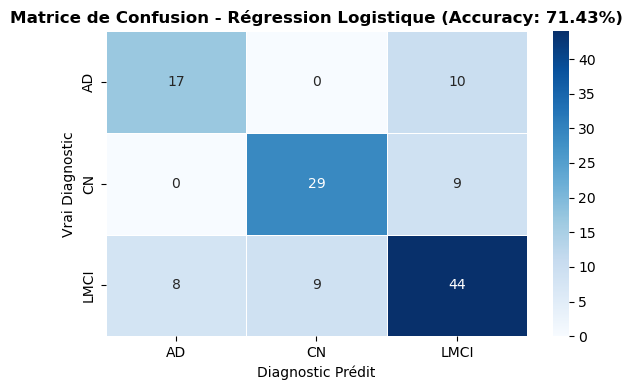

In [28]:
# Matrice de confusion — Régression Logistique
# Lignes = vrais labels | Colonnes = labels prédits
# La diagonale = bonnes prédictions
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.title(f'Matrice de Confusion - Régression Logistique (Accuracy: {acc_lr:.2%})',
          fontsize=12, fontweight='bold')
plt.ylabel('Vrai Diagnostic')
plt.xlabel('Diagnostic Prédit')
plt.tight_layout()
plt.show()

## 6. Modèle 2 — Arbre de Décision

**Principe** : L'arbre pose des questions successives sur les features (ex: "MMSE < 24 ?") pour diviser les patients en groupes de plus en plus homogènes.

**max_depth=4** : on limite la profondeur pour éviter l'overfitting (mémorisation des données d'entraînement).

In [85]:
# Créer et entraîner le modèle
model_dt = DecisionTreeClassifier(
    max_depth=4,       # Profondeur maximale de l'arbre
    random_state=42
)
model_dt.fit(X_train, y_train)

# Prédire et évaluer
y_pred_dt = model_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy : {acc_dt:.2%}\n")
print("Rapport détaillé :")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Accuracy : 67.46%

Rapport détaillé :
              precision    recall  f1-score   support

          AD       1.00      0.52      0.68        27
          CN       0.60      0.76      0.67        38
        LMCI       0.66      0.69      0.67        61

    accuracy                           0.67       126
   macro avg       0.75      0.66      0.68       126
weighted avg       0.71      0.67      0.68       126



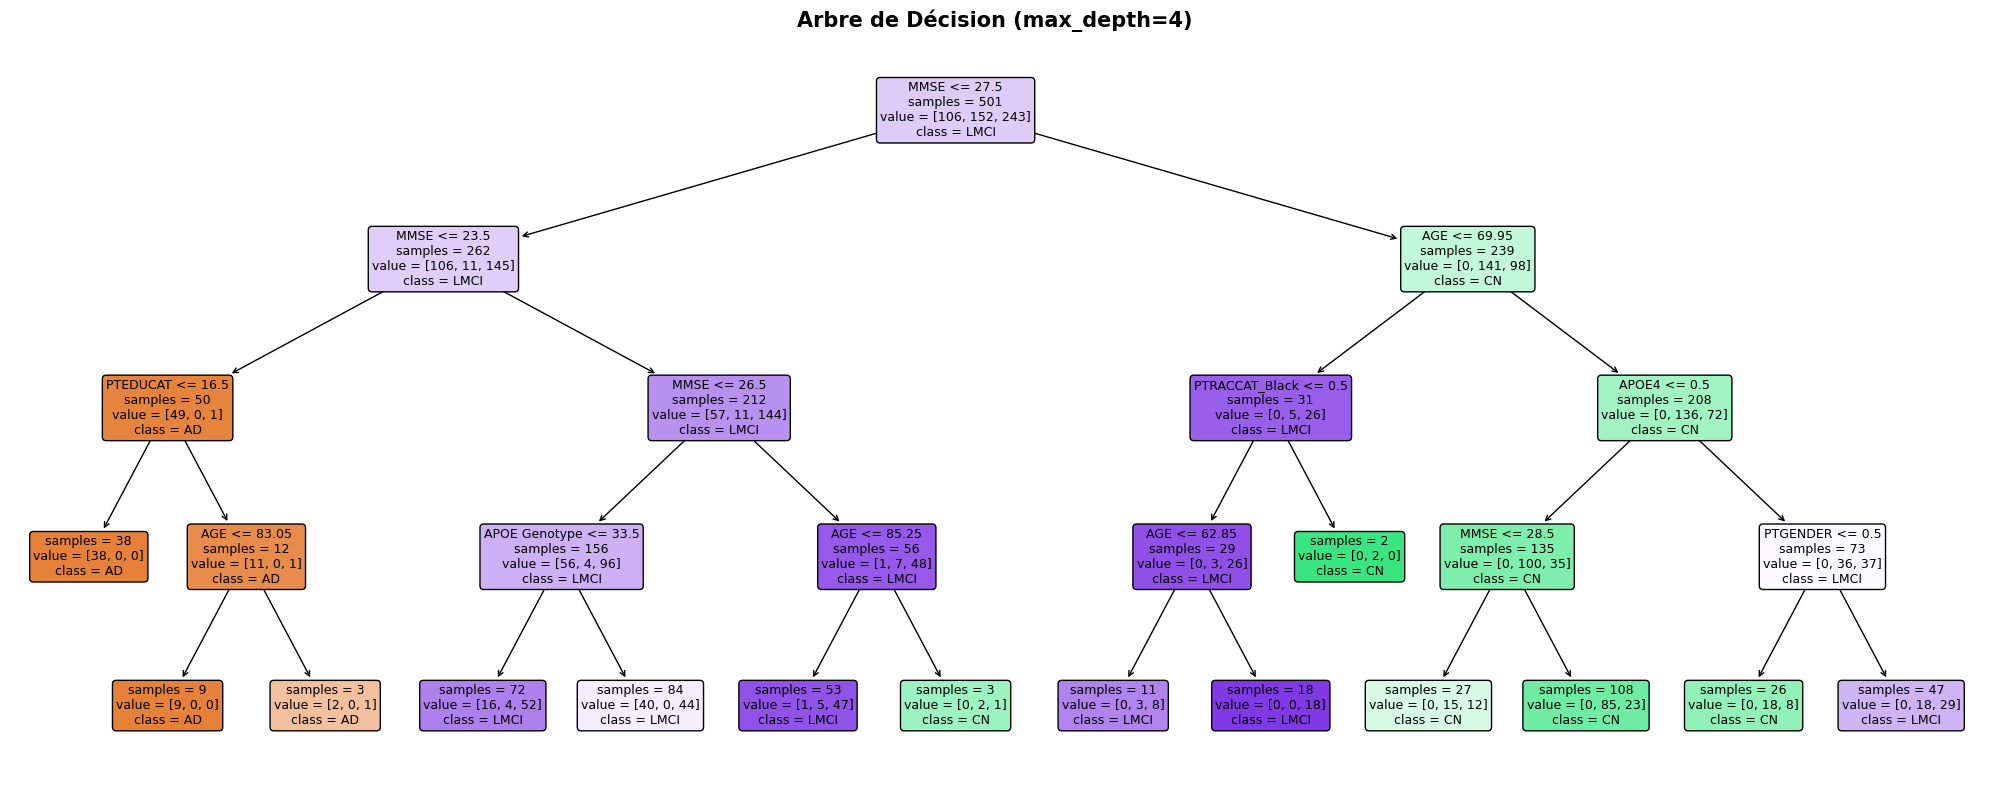

In [31]:
# Visualiser l'arbre de décision
plt.figure(figsize=(20, 8))
plot_tree(
    model_dt,
    feature_names=X.columns.tolist(),
    class_names=le.classes_,
    filled=True,       # Colorier les feuilles selon la classe dominante
    rounded=True,      # Coins arrondis
    fontsize=9,
    impurity=False     # Masquer le Gini pour simplifier la lecture
)
plt.title('Arbre de Décision (max_depth=4)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

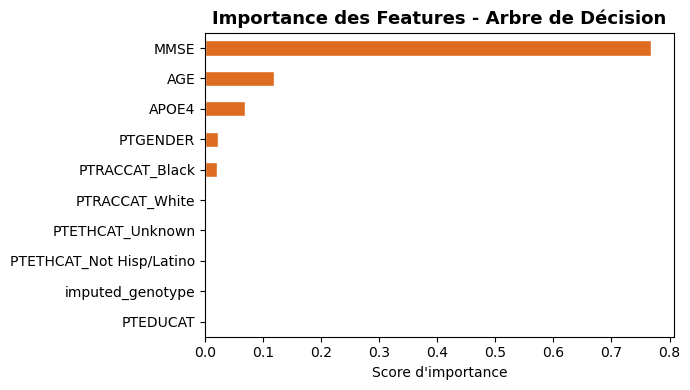

Feature la plus importante : MMSE


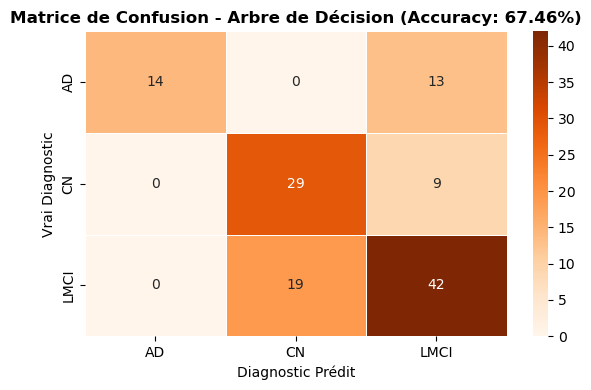

In [87]:
# Importance des features — Arbre de Décision
feat_imp_dt = pd.Series(model_dt.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
feat_imp_dt.plot(kind='barh', color='#dd6b20', edgecolor='white')
plt.title('Importance des Features - Arbre de Décision', fontsize=13, fontweight='bold')
plt.xlabel("Score d'importance")
plt.tight_layout()
plt.show()

print("Feature la plus importante :", feat_imp_dt.idxmax())

# Matrice de confusion
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.title(f'Matrice de Confusion - Arbre de Décision (Accuracy: {acc_dt:.2%})',
          fontsize=12, fontweight='bold')
plt.ylabel('Vrai Diagnostic')
plt.xlabel('Diagnostic Prédit')
plt.tight_layout()
plt.show()

## 7. Modèle 3 — Random Forest

**Principe** : Un Random Forest crée **100 arbres** différents, chacun entraîné sur un sous-ensemble aléatoire des données et des features. Pour prédire, chaque arbre "vote" et on retient la **classe majoritaire**.

**Avantage** : beaucoup plus robuste qu'un seul arbre, résistant à l'overfitting.

In [97]:
# Créer et entraîner le modèle
model_rf = RandomForestClassifier(
    n_estimators=100,  # Nombre d'arbres dans la forêt
    max_depth=5,       # Profondeur max de chaque arbre
    random_state=42
)
model_rf.fit(X_train, y_train)

# Prédire et évaluer
y_pred_rf = model_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy : {acc_rf:.2%}\n")
print("Rapport détaillé :")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Accuracy : 69.84%

Rapport détaillé :
              precision    recall  f1-score   support

          AD       0.81      0.63      0.71        27
          CN       0.67      0.74      0.70        38
        LMCI       0.68      0.70      0.69        61

    accuracy                           0.70       126
   macro avg       0.72      0.69      0.70       126
weighted avg       0.70      0.70      0.70       126



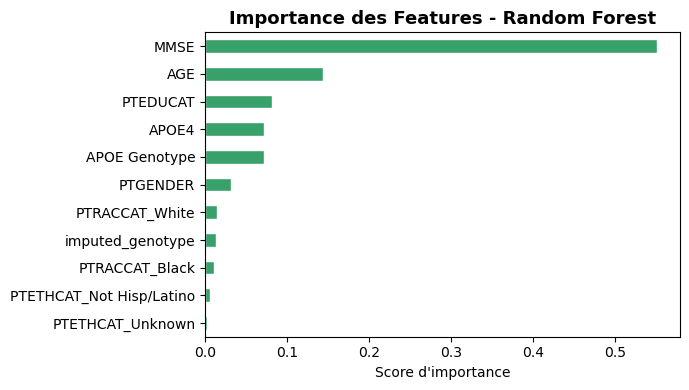

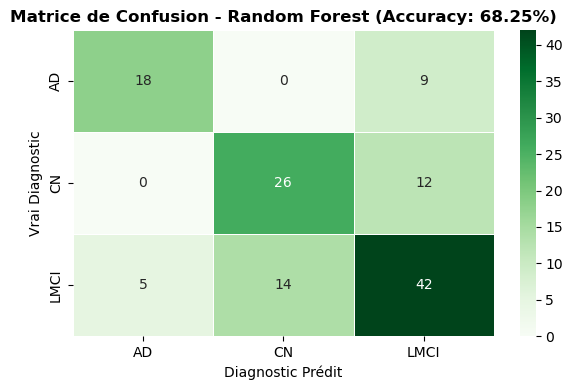

In [35]:
# Importance des features — Random Forest
feat_imp_rf = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
feat_imp_rf.plot(kind='barh', color='#38a169', edgecolor='white')
plt.title('Importance des Features - Random Forest', fontsize=13, fontweight='bold')
plt.xlabel("Score d'importance")
plt.tight_layout()
plt.show()

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.title(f'Matrice de Confusion - Random Forest (Accuracy: {acc_rf:.2%})',
          fontsize=12, fontweight='bold')
plt.ylabel('Vrai Diagnostic')
plt.xlabel('Diagnostic Prédit')
plt.tight_layout()
plt.show()

## 8. Modèle 4 — XGBoost

**Principe** : XGBoost construit les arbres de façon **séquentielle** : chaque nouvel arbre apprend à corriger les erreurs du précédent. C'est l'algorithme qui remporte le plus de compétitions ML.

**learning_rate=0.1** : vitesse à laquelle le modèle apprend.

In [99]:
# Créer et entraîner le modèle
model_xgb = XGBClassifier(
    n_estimators=100,         # Nombre d'arbres
    max_depth=4,              # Profondeur max
    learning_rate=0.1,        # Vitesse d'apprentissage
    eval_metric='mlogloss',   # Métrique pour classification multi-classe
    random_state=42,
    verbosity=0               # Pas de messages pendant l'entraînement
)
model_xgb.fit(X_train, y_train)

# Prédire et évaluer
y_pred_xgb = model_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"Accuracy : {acc_xgb:.2%}\n")
print("Rapport détaillé :")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

Accuracy : 69.05%

Rapport détaillé :
              precision    recall  f1-score   support

          AD       0.76      0.70      0.73        27
          CN       0.64      0.74      0.68        38
        LMCI       0.70      0.66      0.68        61

    accuracy                           0.69       126
   macro avg       0.70      0.70      0.70       126
weighted avg       0.69      0.69      0.69       126



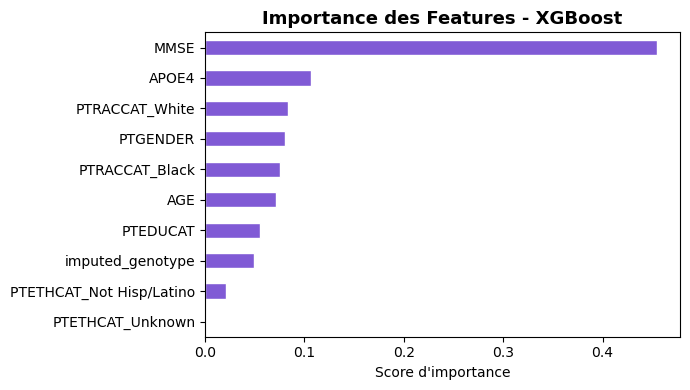

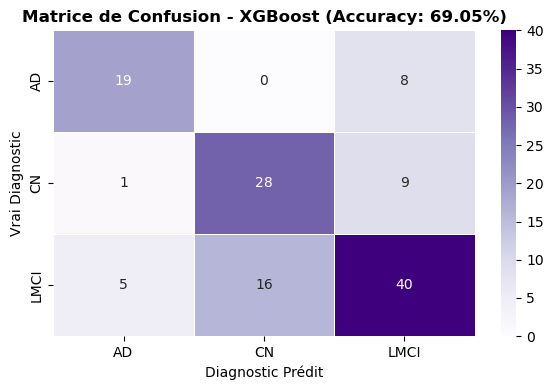

In [101]:
# Importance des features — XGBoost
feat_imp_xgb = pd.Series(model_xgb.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
feat_imp_xgb.plot(kind='barh', color='#805ad5', edgecolor='white')
plt.title('Importance des Features - XGBoost', fontsize=13, fontweight='bold')
plt.xlabel("Score d'importance")
plt.tight_layout()
plt.show()

# Matrice de confusion
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.title(f'Matrice de Confusion - XGBoost (Accuracy: {acc_xgb:.2%})',
          fontsize=12, fontweight='bold')
plt.ylabel('Vrai Diagnostic')
plt.xlabel('Diagnostic Prédit')
plt.tight_layout()
plt.show()

## 9. Comparaison des 4 Modèles

In [103]:
# Tableau récapitulatif
resultats = pd.DataFrame({
    'Modele': ['Regression Logistique', 'Arbre de Decision', 'Random Forest', 'XGBoost'],
    'Accuracy': [acc_lr, acc_dt, acc_rf, acc_xgb],
    'Accuracy (%)': [f"{a:.2%}" for a in [acc_lr, acc_dt, acc_rf, acc_xgb]]
})
resultats = resultats.sort_values('Accuracy', ascending=False).reset_index(drop=True)
resultats.index = resultats.index + 1
print("=== CLASSEMENT DES MODELES ===")
print(resultats.to_string())

=== CLASSEMENT DES MODELES ===
                  Modele  Accuracy Accuracy (%)
1  Regression Logistique  0.698413       69.84%
2          Random Forest  0.698413       69.84%
3                XGBoost  0.690476       69.05%
4      Arbre de Decision  0.674603       67.46%


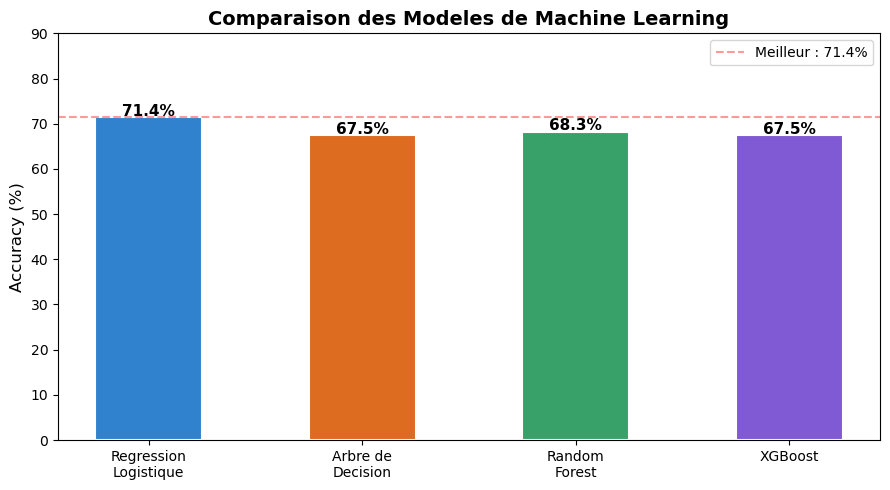

In [41]:
# Graphique de comparaison
modeles_noms = ['Regression\nLogistique', 'Arbre de\nDecision', 'Random\nForest', 'XGBoost']
accuracies = [acc_lr * 100, acc_dt * 100, acc_rf * 100, acc_xgb * 100]
colors_bar = ['#3182ce', '#dd6b20', '#38a169', '#805ad5']

plt.figure(figsize=(9, 5))
bars = plt.bar(modeles_noms, accuracies, color=colors_bar, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.ylim(0, 90)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Comparaison des Modeles de Machine Learning', fontsize=14, fontweight='bold')
plt.axhline(y=max(accuracies), color='red', linestyle='--', alpha=0.4, label=f'Meilleur : {max(accuracies):.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

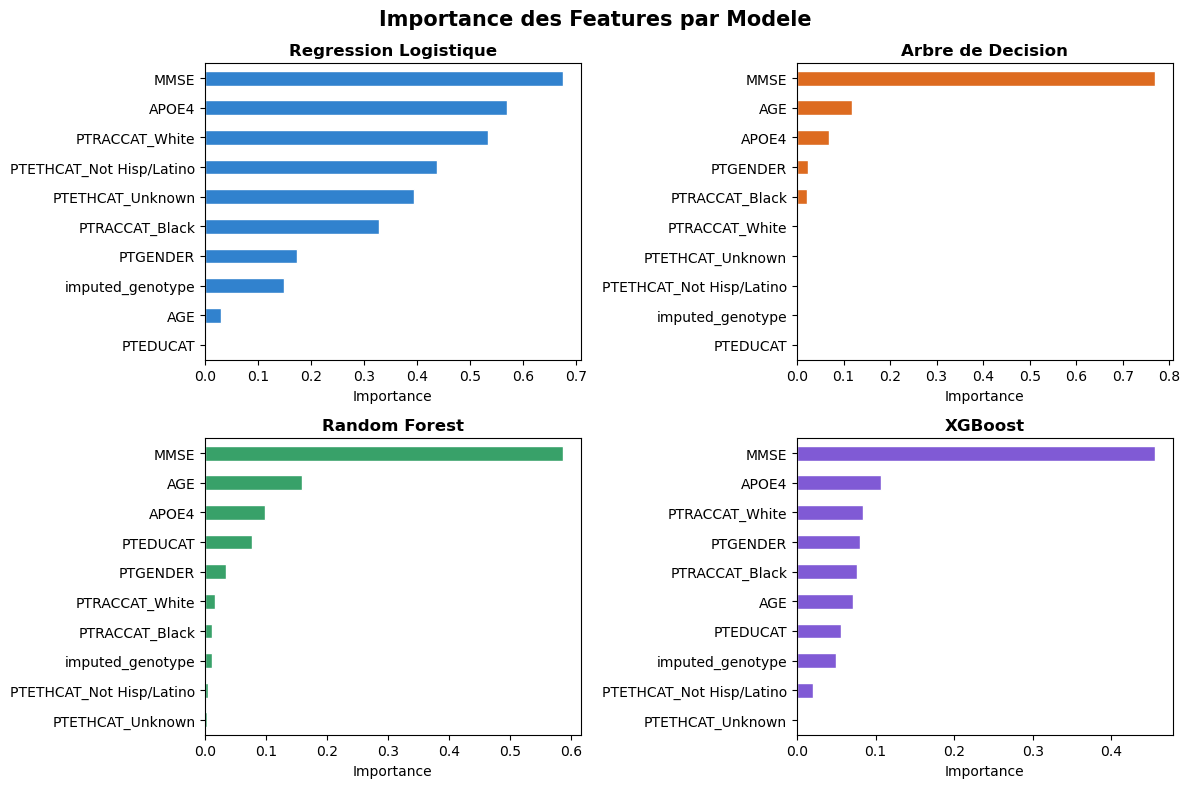

In [105]:
# Comparaison des importances de features (tous modeles)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Importance des Features par Modele', fontsize=15, fontweight='bold')

configs = [
    (model_lr, 'Regression Logistique', '#3182ce', axes[0, 0]),
    (model_dt, 'Arbre de Decision',     '#dd6b20', axes[0, 1]),
    (model_rf, 'Random Forest',          '#38a169', axes[1, 0]),
    (model_xgb, 'XGBoost',              '#805ad5', axes[1, 1]),
]

for model, name, color, ax in configs:
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        imp = np.abs(model.coef_).mean(axis=0)
    pd.Series(imp, index=X.columns).sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 10. Conclusion

### Resume des resultats

| Modèle | Avantages | Inconvénients |
|--------|-----------|---------------|
| Régression Logistique | Rapide, interprétable | Moins performant |
| Arbre de Décision | Très visuel, intuitif | Tendency à l'overfitting |
| Random Forest | Robuste, précis | Moins interprétable |
| XGBoost | Très performant | Paramètres plus complexes |

### Observations clés

- **MMSE est la feature la plus importante** : le score cognitif est le meilleur prédicteur
- **APOE4 arrive en deuxième** : le marqueur génétique apporte une information complémentaire
- La distinction **LMCI vs CN/AD** est la plus difficile

---
*Dataset : ADNI (Alzheimer's Disease Neuroimaging Initiative) — 628 patients*

In [107]:
# Resume final
print("=" * 50)
print("         RESUME FINAL DU PROJET")
print("=" * 50)
print(f"Dataset       : ADNI - {len(df)} patients, {len(X.columns)} features")
print(f"Target        : DX.bl (CN / LMCI / AD)")
print()
print("Resultats des modeles :")
print(f"  Regression Logistique : {acc_lr:.2%}")
print(f"  Arbre de Decision     : {acc_dt:.2%}")
print(f"  Random Forest         : {acc_rf:.2%}")
print(f"  XGBoost               : {acc_xgb:.2%}")
print()
best_list = [acc_lr, acc_dt, acc_rf, acc_xgb]
best_name = ['Regression Logistique', 'Arbre de Decision', 'Random Forest', 'XGBoost']
winner = best_name[best_list.index(max(best_list))]
print(f"Meilleur modele : {winner} ({max(best_list):.2%})")
print("=" * 50)

         RESUME FINAL DU PROJET
Dataset       : ADNI - 627 patients, 10 features
Target        : DX.bl (CN / LMCI / AD)

Resultats des modeles :
  Regression Logistique : 69.84%
  Arbre de Decision     : 67.46%
  Random Forest         : 69.84%
  XGBoost               : 69.05%

Meilleur modele : Regression Logistique (69.84%)
